# Modèle Âge V3 - MobileNetV3Small + CBAM Attention

**Changements par rapport à V2:**

- **Backbone MobileNetV3Small** (au lieu d'EfficientNetB0)
- CBAM Attention (Channel + Spatial) conservé
- Même pipeline de données avec Mixup et rotation
- Fine-tuning en 2 phases

**Avantages de MobileNetV3Small:**

- ~2.5M paramètres (vs ~5.3M pour EfficientNetB0)
- 2-3x plus rapide sur mobile
- TFLite plus petit (~6MB vs ~15MB)


In [ ]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


2026-03-23 11:54:35.581432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 11:54:35.802744: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 11:54:35.870925: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.17.1
GPU disponible: []


2026-03-23 11:54:46.127822: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: UNKNOWN ERROR (100)


## Configuration


In [ ]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("age", "age_model_v3_mobilenet")
ARTIFACTS_DIR = OUTPUT_DIR

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 30
FINETUNE_EPOCHS = 60
INITIAL_LR = 3e-4
FINETUNE_LR = 5e-6

# Huber Loss
HUBER_DELTA = 3.0

# Mixup
MIXUP_ALPHA = 0.2

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

# Buckets d'âge pour stratification
AGE_BINS = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 120]
AGE_LABELS = [
    "0-5",
    "6-10",
    "11-15",
    "16-20",
    "21-25",
    "26-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "70+",
]

print(f"Configuration V3 (MobileNetV3Small):")
print(f"  - Backbone: MobileNetV3Small")
print(f"  - Huber Loss delta: {HUBER_DELTA}")
print(f"  - Mixup alpha: {MIXUP_ALPHA}")
print(f"  - Warmup epochs: {WARMUP_EPOCHS}")
print(f"  - Fine-tune epochs: {FINETUNE_EPOCHS}")

Configuration V3 (MobileNetV3Small):
  - Backbone: MobileNetV3Small
  - Huber Loss delta: 3.0
  - Mixup alpha: 0.2
  - Warmup epochs: 30
  - Fine-tune epochs: 60


## Chargement des Données


In [3]:
def parse_utkface_filename(filepath):
    try:
        name = Path(filepath).name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 1 or not parts[0].isdigit():
            return None
        age = int(parts[0])
        if age < 0 or age > 116:
            return None
        return {"filepath": str(filepath), "age": age}
    except Exception:
        return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

records = []
for path in tqdm(image_paths, desc="Parsing"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"Images valides: {len(df)}")

# Supprimer outliers
z_scores = np.abs(stats.zscore(df["age"]))
df_clean = df[z_scores <= 3].copy()
print(f"Images après nettoyage: {len(df_clean)}")
print(f"Plage d'âge: {df_clean['age'].min()} - {df_clean['age'].max()}")

Images trouvées: 23708


Parsing:   0%|          | 0/23708 [00:00<?, ?it/s]

Images valides: 23708
Images après nettoyage: 23636
Plage d'âge: 1 - 92


In [4]:
# Créer les buckets d'âge
df_clean["age_bucket"] = pd.cut(df_clean["age"], bins=AGE_BINS, labels=AGE_LABELS)

# Distribution
bucket_counts = df_clean["age_bucket"].value_counts().sort_index()
print("Distribution par bucket d'âge:")
print(bucket_counts)

Distribution par bucket d'âge:
age_bucket
0-5      2363
6-10      855
11-15     610
16-20    1049
21-25    2760
26-30    5024
31-40    4339
41-50    2100
51-60    2211
61-70    1172
70+      1153
Name: count, dtype: int64


## Split et Oversampling


In [5]:
# Split stratifié
X = df_clean["filepath"].values
y = df_clean["age"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=df_clean["age_bucket"]
)

trainval_buckets = pd.cut(y_trainval, bins=AGE_BINS, labels=AGE_LABELS)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=trainval_buckets,
)

print(f"Split:")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")

Split:
  - Train: 18908
  - Val: 2364
  - Test: 2364


In [6]:
def oversample_age_buckets(
    X, y, age_bins, age_labels, target_ratio=2.0, young_boost=None
):
    """Oversampling avec focus sur les jeunes."""
    buckets = pd.cut(y, bins=age_bins, labels=age_labels)
    bucket_counts = pd.Series(buckets).value_counts()
    target_count = int(bucket_counts.median() * target_ratio)

    if young_boost is None:
        young_boost = ["0-5", "6-10", "11-15", "16-20"]

    X_resampled, y_resampled = [], []

    for bucket in age_labels:
        mask = buckets == bucket
        X_bucket = X[mask]
        y_bucket = y[mask]
        current_count = len(X_bucket)

        if current_count == 0:
            continue

        if bucket in young_boost:
            bucket_target = int(target_count * 2.0)
        else:
            bucket_target = target_count

        if current_count < bucket_target:
            repeats = (bucket_target // current_count) + 1
            X_bucket = np.tile(X_bucket, repeats)[:bucket_target]
            y_bucket = np.tile(y_bucket, repeats)[:bucket_target]

        X_resampled.extend(X_bucket)
        y_resampled.extend(y_bucket)

    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


X_train_balanced, y_train_balanced = oversample_age_buckets(
    X_train, y_train, AGE_BINS, AGE_LABELS
)
print(f"\nAprès oversampling: {len(X_train_balanced)} (était {len(X_train)})")


Après oversampling: 51169 (était 18908)


## Data Pipeline avec Mixup


In [7]:
# Data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.25),  # ±45°
        layers.RandomZoom((-0.2, 0.2)),
        layers.RandomTranslation(0.15, 0.15),
        layers.RandomBrightness(0.25),
        layers.RandomContrast(0.25),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label


def mixup_regression(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    lam = tf.random.uniform([], 0.5, 1.0)
    indices = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1 - lam) * tf.gather(images, indices)
    mixed_labels = lam * labels + (1 - lam) * tf.gather(labels, indices)
    return mixed_images, mixed_labels


def create_dataset(
    filepaths, labels, batch_size, shuffle=True, augment=False, use_mixup=False
):
    labels = labels.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    if use_mixup:
        ds = ds.map(
            lambda x, y: mixup_regression(x, y, MIXUP_ALPHA),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train_balanced,
    y_train_balanced,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    use_mixup=True,
)
val_ds = create_dataset(
    X_val, y_val, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)
test_ds = create_dataset(
    X_test, y_test, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)

print("Datasets créés avec Mixup!")

Datasets créés avec Mixup!


## Modèle avec CBAM Attention + MobileNetV3Small


In [8]:
def squeeze_excitation_block(x, ratio=16, name_prefix="se"):
    """Squeeze-Excitation (Channel) attention block."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    se = layers.Dense(filters // ratio, activation="relu", name=f"{name_prefix}_fc1")(
        se
    )
    se = layers.Dense(filters, activation="sigmoid", name=f"{name_prefix}_fc2")(se)
    se = layers.Reshape((1, 1, filters), name=f"{name_prefix}_reshape")(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def spatial_attention_block(x, kernel_size=7, name_prefix="spatial"):
    """Spatial Attention Block - focus sur les zones de rides."""
    avg_pool = keras.ops.mean(x, axis=-1, keepdims=True)
    max_pool = keras.ops.max(x, axis=-1, keepdims=True)
    concat = layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(
        [avg_pool, max_pool]
    )
    attention = layers.Conv2D(
        1,
        kernel_size=kernel_size,
        padding="same",
        activation="sigmoid",
        name=f"{name_prefix}_conv",
    )(concat)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, attention])


def cbam_block(x, ratio=16, kernel_size=7, name_prefix="cbam"):
    """CBAM: Channel + Spatial Attention."""
    x = squeeze_excitation_block(x, ratio=ratio, name_prefix=f"{name_prefix}_se")
    x = spatial_attention_block(
        x, kernel_size=kernel_size, name_prefix=f"{name_prefix}_spatial"
    )
    return x


def build_age_model_v3(img_size, trainable_backbone=False):
    """
    Modèle V3 avec MobileNetV3Small + CBAM Attention.

    Changement: EfficientNetB0 -> MobileNetV3Small
    """
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # ════════════════════════════════════════════════════════════
    # BACKBONE: MobileNetV3Small
    # ════════════════════════════════════════════════════════════
    backbone = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # CBAM attention (Channel + Spatial) - pour focus sur zones de rides
    x = cbam_block(x, ratio=16, kernel_size=7, name_prefix="cbam")

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head de régression
    x = layers.Dense(
        512, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_1"
    )(x)
    x = layers.BatchNormalization(name="head_bn_1")(x)
    x = layers.Activation("relu", name="head_relu_1")(x)
    x = layers.Dropout(0.5, name="head_dropout_1")(x)

    x = layers.Dense(
        256, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_2"
    )(x)
    x = layers.BatchNormalization(name="head_bn_2")(x)
    x = layers.Activation("relu", name="head_relu_2")(x)
    x = layers.Dropout(0.4, name="head_dropout_2")(x)

    x = layers.Dense(
        128, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_3"
    )(x)
    x = layers.BatchNormalization(name="head_bn_3")(x)
    x = layers.Activation("relu", name="head_relu_3")(x)
    x = layers.Dropout(0.3, name="head_dropout_3")(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_4")(
        x
    )
    x = layers.BatchNormalization(name="head_bn_4")(x)
    x = layers.Activation("relu", name="head_relu_4")(x)
    x = layers.Dropout(0.2, name="head_dropout_4")(x)

    outputs = layers.Dense(1, activation="linear", name="age_output")(x)

    model = Model(inputs, outputs, name="AgeModel_V3_MobileNet")
    return model, backbone


model, backbone = build_age_model_v3(IMG_SIZE, trainable_backbone=False)

print(f"\n{'='*60}")
print(f"MODÈLE ÂGE V3 - MobileNetV3Small")
print(f"{'='*60}")
print(f"Backbone: MobileNetV3Small ({len(backbone.layers)} couches)")
print(f"Total params: {model.count_params():,}")
model.summary()


MODÈLE ÂGE V3 - MobileNetV3Small
Backbone: MobileNetV3Small (157 couches)
Total params: 1,748,024


Model: "AgeModel_V3_MobileNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Small    │ (None, 4, 4, 576) │    939,120 │ input_image[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_se_gap         │ (None, 576)       │          0 │ MobileNetV3Small… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_se_fc1 (Dense) │ (None, 36)        │     20,772 │ cbam_se_gap[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_se_fc2 (Dense) │ (None, 576)       │     21,312 │ cbam_se_fc1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_se_reshape     │ (None, 1, 1, 576) │          0 │ cbam_se_fc2[0][0] │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_se_scale       │ (None, 4, 4, 576) │          0 │ MobileNetV3Small… │
│ (Multiply)          │                   │            │ cbam_se_reshape[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Mean)         │ (None, 4, 4, 1)   │          0 │ cbam_se_scale[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max (Max)           │ (None, 4, 4, 1)   │          0 │ cbam_se_scale[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_spatial_concat │ (None, 4, 4, 2)   │          0 │ mean[0][0],       │
│ (Concatenate)       │                   │            │ max[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_spatial_conv   │ (None, 4, 4, 1)   │         99 │ cbam_spatial_con… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbam_spatial_scale  │ (None, 4, 4, 576) │          0 │ cbam_se_scale[0]… │
│ (Multiply)          │                   │            │ cbam_spatial_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 576)       │          0 │ cbam_spatial_sca… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 576)       │          0 │ cbam_spatial_sca… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 1152)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_1        │ (None, 512)       │    590,336 │ concat_pool[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_bn_1           │ (None, 512)       │      2,048 │ head_dense_1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_relu_1         │ (None, 512)       │          0 │ head_bn_1[0][0]   │
│ (Activation)        │                   │            │                 

 Total params: 1,748,024 (6.67 MB)

 Trainable params: 806,984 (3.08 MB)

 Non-trainable params: 941,040 (3.59 MB)

## Phase 1: Warmup


In [9]:
steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
)

model.compile(
    optimizer=AdamW(learning_rate=warmup_lr_schedule, weight_decay=1e-5),
    loss=Huber(delta=HUBER_DELTA),
    metrics=["mae", "mse"],
)

warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae", patience=15, restore_best_weights=True, mode="min", verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_v3_mobilenet_warmup.keras"),
        monitor="val_mae",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(f"Loss: Huber (delta={HUBER_DELTA})")

Phase 1: Warmup (30 epochs, backbone gelé)
Loss: Huber (delta=3.0)


In [10]:
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/30


I0000 00:00:1769589543.938936    6352 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1600/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 61.8007 - mae: 22.0005 - mse: 815.3268
Epoch 1: val_mae improved from None to 11.56316, saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_warmup.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_warmup.keras
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 60s 26ms/step - loss: 48.9827 - mae: 17.7037 - mse: 581.6163 - val_loss: 30.7194 - val_mae: 11.5632 - val_mse: 248.6344
Epoch 2/30
1598/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 29.3029 - mae: 11.1169 - mse: 226.2699
Epoch 2: val_mae improved from 11.56316 to 9.94053, saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_warmup.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_warmup.keras
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 28.8769 - mae: 10.9741 - mse: 219.4906 - val_loss: 25.7542 - val_mae: 9.9405 - val_mse: 174.2496
Epoch 3/30
1600/1600 ━━━━━━━━━━

## Phase 2: Fine-tuning


In [11]:
# Dégeler les dernières couches du backbone
# MobileNetV3Small a ~158 couches, on en dégèle 50
backbone.trainable = True

freeze_until = len(backbone.layers) - 50
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (60 epochs)
Couches dégelées: 50/157
Paramètres entraînables: 1,543,568


In [12]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.01,
)

model.compile(
    optimizer=AdamW(learning_rate=finetune_lr_schedule, weight_decay=1e-4),
    loss=Huber(delta=HUBER_DELTA),
    metrics=["mae", "mse"],
)

finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae", patience=20, restore_best_weights=True, mode="min", verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_v3_mobilenet_best.keras"),
        monitor="val_mae",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
]

In [13]:
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/60
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 29.0243 - mae: 11.0046 - mse: 218.8376
Epoch 1: val_mae improved from None to 10.07768, saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_best.keras
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 59s 26ms/step - loss: 28.4627 - mae: 10.8151 - mse: 213.1752 - val_loss: 26.2410 - val_mae: 10.0777 - val_mse: 195.9407
Epoch 2/60
1599/1600 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 27.3714 - mae: 10.4451 - mse: 201.3785
Epoch 2: val_mae improved from 10.07768 to 9.71772, saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_best.keras
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - loss: 27.1091 - mae: 10.3556 - mse: 198.7194 - val_loss: 25.1881 - val_mae: 9.7177 - val_mse: 176.8041
Epoch 3/60
1597/1600 ━━━━━━━

## Évaluation


In [14]:
best_model = keras.models.load_model(ARTIFACTS_DIR / "age_v3_mobilenet_best.keras")

# Prédictions
y_pred = best_model.predict(test_ds, verbose=1).flatten()
y_true = y_test

# Métriques
mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\n{'='*60}")
print(f"RÉSULTATS V3 (MobileNetV3Small) SUR LE TEST SET")
print(f"{'='*60}")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

RÉSULTATS V3 (MobileNetV3Small) SUR LE TEST SET
  - MAE: 8.04 années
  - RMSE: 10.76 années
  - R² Score: 0.6972


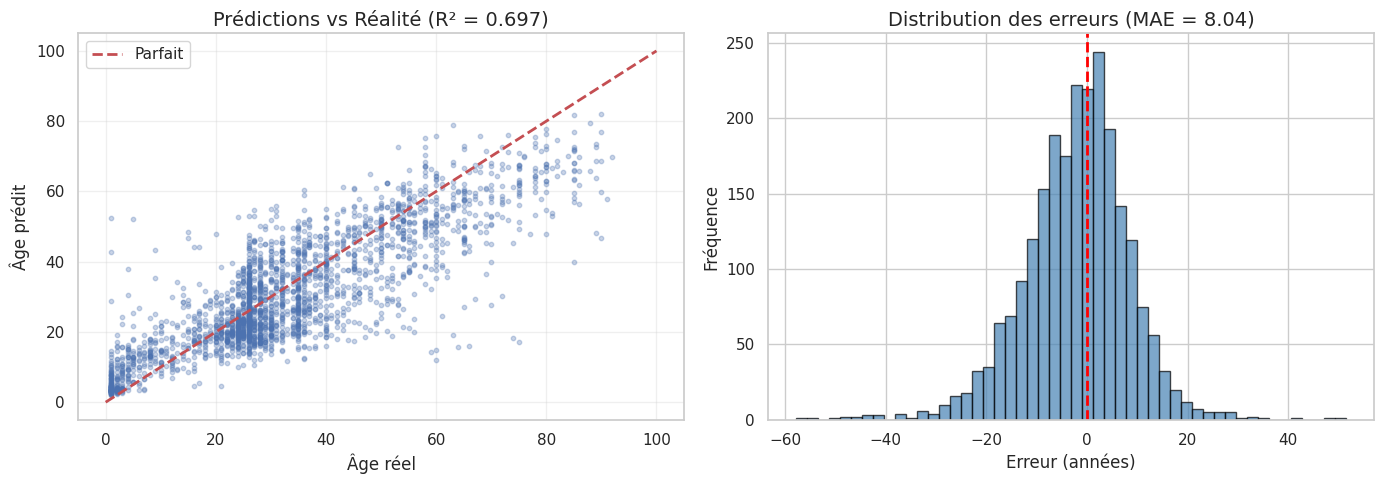

In [15]:
# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0].plot([0, 100], [0, 100], "r--", linewidth=2, label="Parfait")
axes[0].set_xlabel("Âge réel")
axes[0].set_ylabel("Âge prédit")
axes[0].set_title(f"Prédictions vs Réalité (R² = {r2:.3f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des erreurs
errors = y_pred - y_true
axes[1].hist(errors, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Erreur (années)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title(f"Distribution des erreurs (MAE = {mae:.2f})")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_v3_mobilenet_analysis.png", dpi=150)
plt.show()

## Sauvegarde et Conversion TFLite


In [16]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "age_v3_mobilenet_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les infos
import json

model_info = {
    "version": "3.0",
    "backbone": "MobileNetV3Small",
    "img_size": IMG_SIZE,
    "task": "regression",
    "input_range": [0, 255],
    "age_range": [0, 116],
    "features": [
        "MobileNetV3Small backbone",
        "CBAM Attention (Channel + Spatial)",
        "Rotation agressive (±45°)",
        "Mixup",
        "Huber Loss",
        "AdamW + L2",
    ],
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
    },
}

with open(ARTIFACTS_DIR / "age_v3_mobilenet_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print("Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_final.keras
Infos du modèle sauvegardées


In [17]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "age_v3_mobilenet.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size_mb = tflite_path.stat().st_size / 1024 / 1024
print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpnzqfnmnn/assets


INFO:tensorflow:Assets written to: /tmp/tmpnzqfnmnn/assets


Saved artifact at '/tmp/tmpnzqfnmnn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140701386196368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386196176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386196752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386198480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140703497442064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386198096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386197328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386197136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386196944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140701386197904

W0000 00:00:1769588538.320296    6135 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769588538.320320    6135 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1769588538.394258    6135 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## Résumé Final


In [18]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE ÂGE V3 (MobileNetV3Small)")
print("=" * 60)
print(f"\nArchitecture: MobileNetV3Small + CBAM Attention + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Dataset: {len(df_clean)} images")
print(f"\nPerformances sur le test set:")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")
print(f"\nTaille TFLite: {tflite_size_mb:.2f} MB")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE ÂGE V3 (MobileNetV3Small)

Architecture: MobileNetV3Small + CBAM Attention + Dense Head
Input size: 128x128x3
Dataset: 23636 images

Performances sur le test set:
  - MAE: 8.04 années
  - RMSE: 10.76 années
  - R² Score: 0.6972

Taille TFLite: 3.36 MB

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet_final.keras
  - /home/optimalako/Projet/SAE/artifacts/age_v3_mobilenet.tflite
